## Exercise II: Profiling Diffusion Process Code

In [1]:
import cProfile

### Task 2.1 Profile the diffusion code with cProfile and line_profiler the computation

We first define the functions used in the diffusion python file for easier use in the notebook

In [12]:
grid_shape = (640, 640)


def evolve(grid, dt, D=1.0):
    xmax, ymax = grid_shape
    new_grid = [[0.0] * ymax for x in range(xmax)]
    for i in range(xmax):
        for j in range(ymax):
            grid_xx = (
                grid[(i + 1) % xmax][j] + grid[(i - 1) % xmax][j] - 2.0 * grid[i][j]
            )
            grid_yy = (
                grid[i][(j + 1) % ymax] + grid[i][(j - 1) % ymax] - 2.0 * grid[i][j]
            )
            new_grid[i][j] = grid[i][j] + D * (grid_xx + grid_yy) * dt
    return new_grid


def run_experiment(num_iterations):
    # Setting up initial conditions 
    xmax, ymax = grid_shape
    grid = [[0.0] * ymax for x in range(xmax)]

    # These initial conditions are simulating a drop of dye in the middle of our
    # simulated region
    block_low = int(grid_shape[0] * 0.4)
    block_high = int(grid_shape[0] * 0.5)
    for i in range(block_low, block_high):
        for j in range(block_low, block_high):
            grid[i][j] = 0.005

    # Evolve the initial conditions
    for i in range(num_iterations):
        grid = evolve(grid, 0.1)

#### Profiling with cProfile

We use cProfile to measure where the program spends its execution time. It does this by tracking function calls and their durations. By doing this we can show what functions consume the most time, allowing us to focus our optimization efforts on the most impactful areas of our code.

In [3]:
cProfile.run('run_experiment(10)', 'profile.stats')

We use snakeviz to visualize the output of the cProfile run

In [4]:
!snakeviz profile.stats

snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2FUsers%2Fakira%2FHPC-Intro%2FAssignment1%2Fprofile.stats
^C


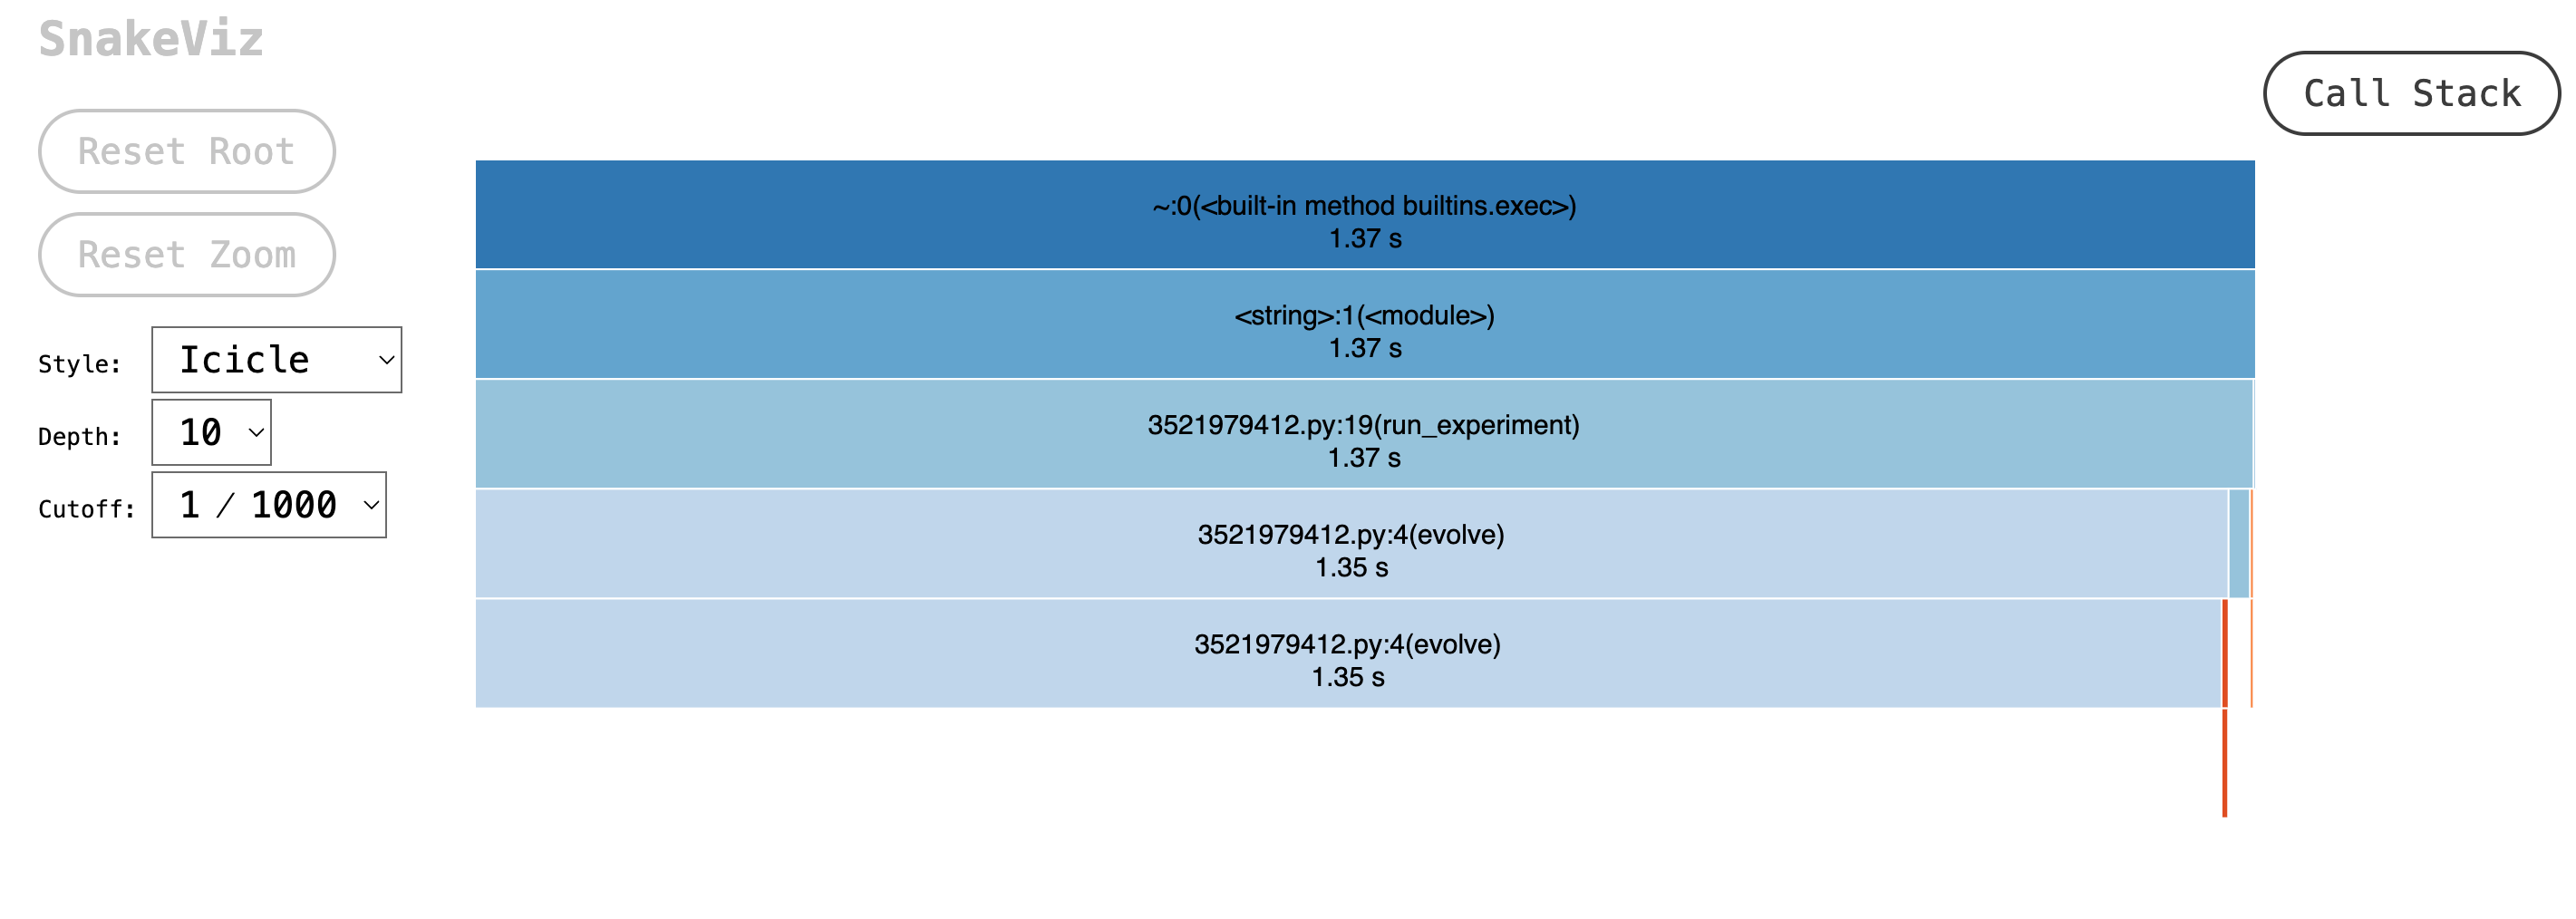

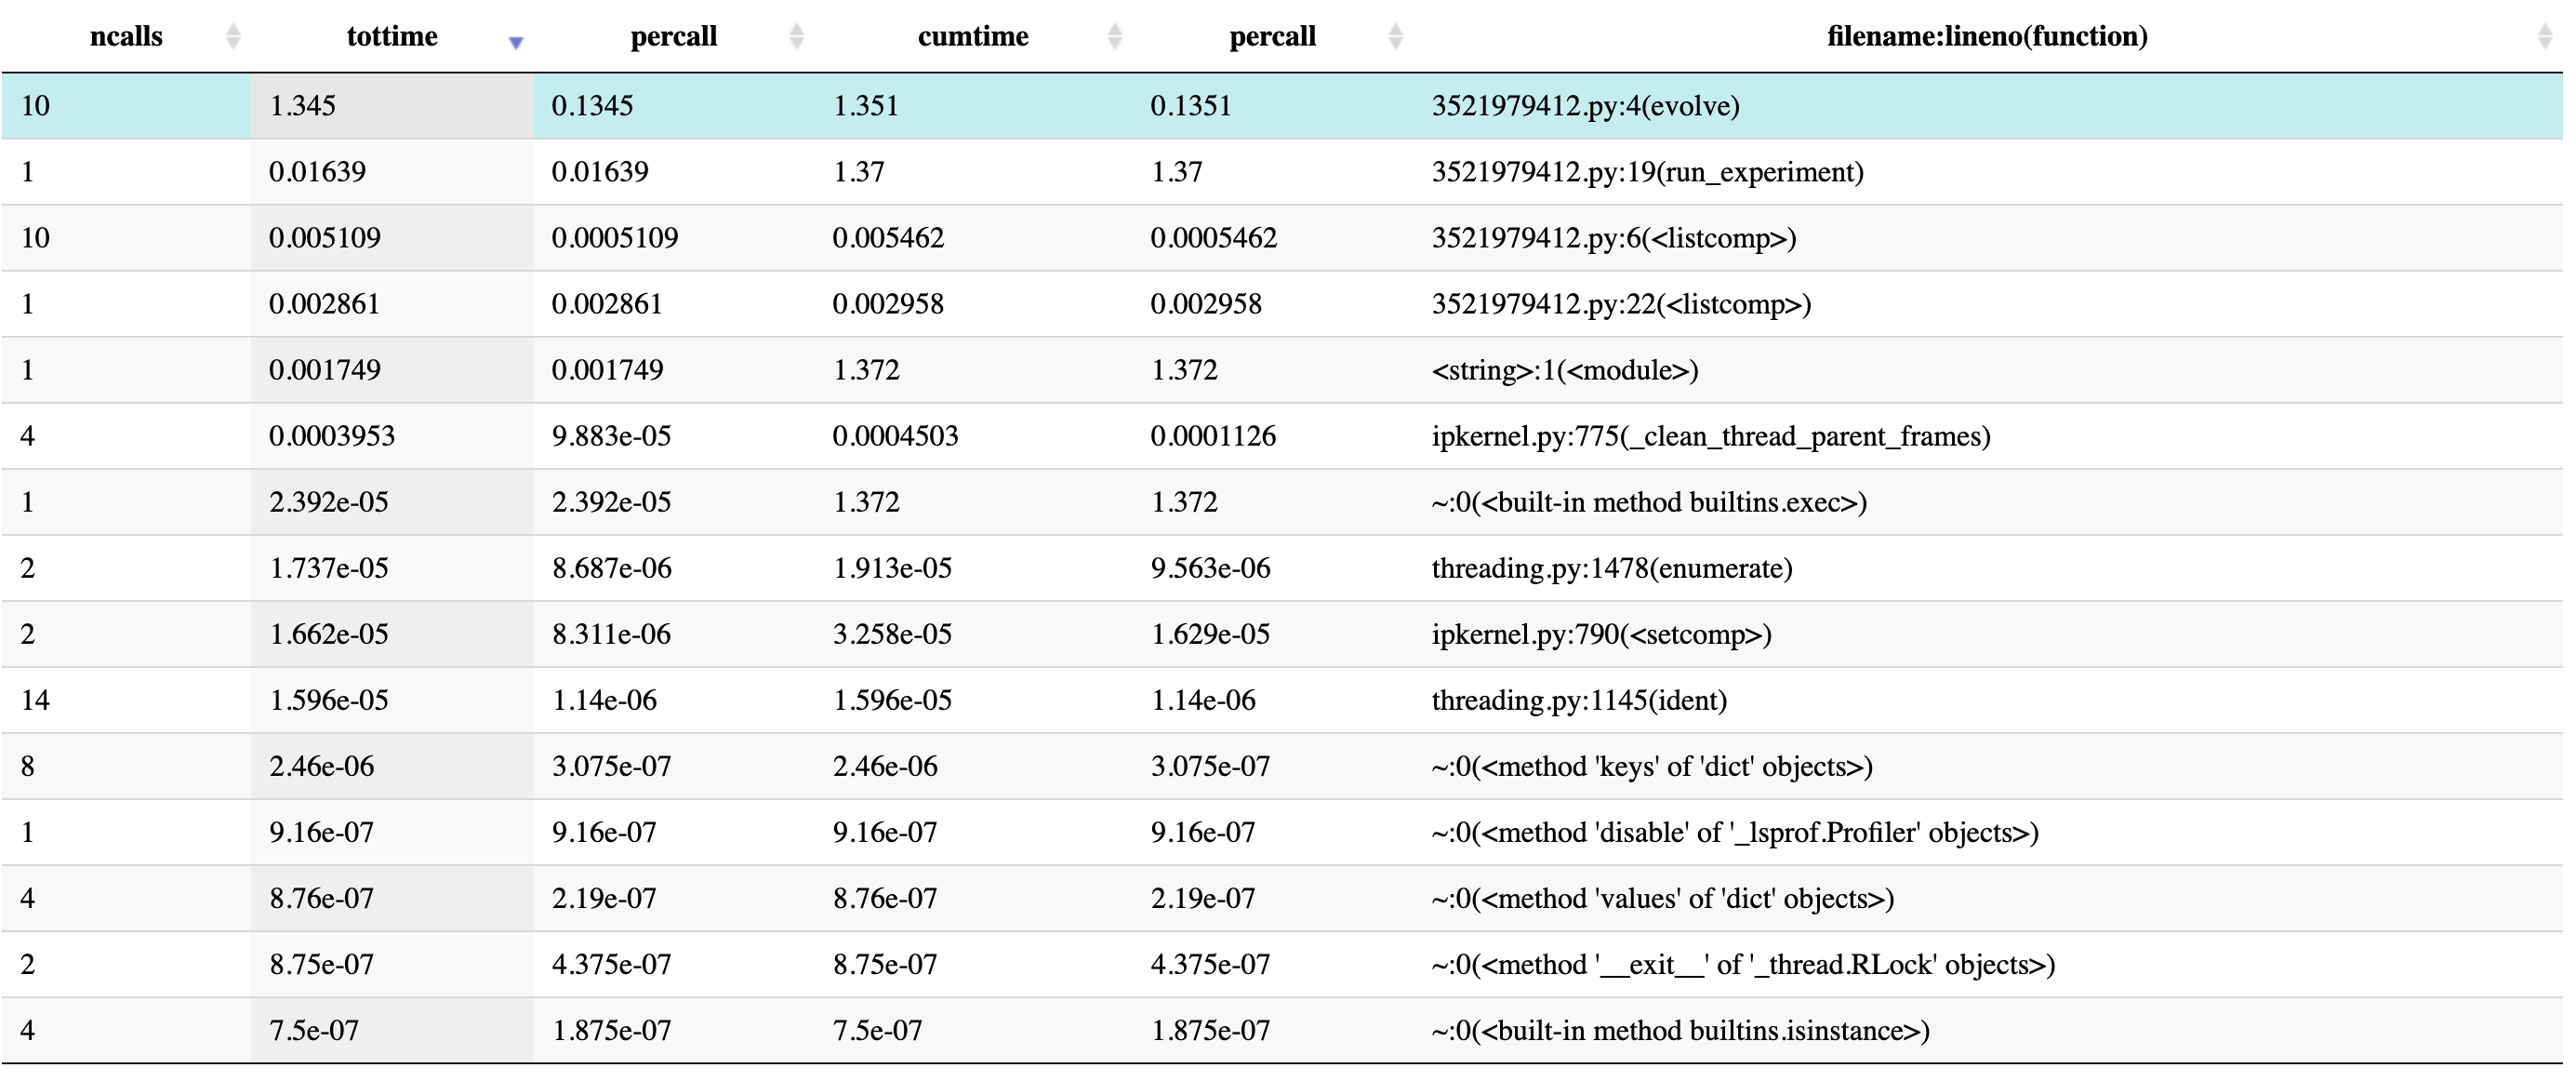

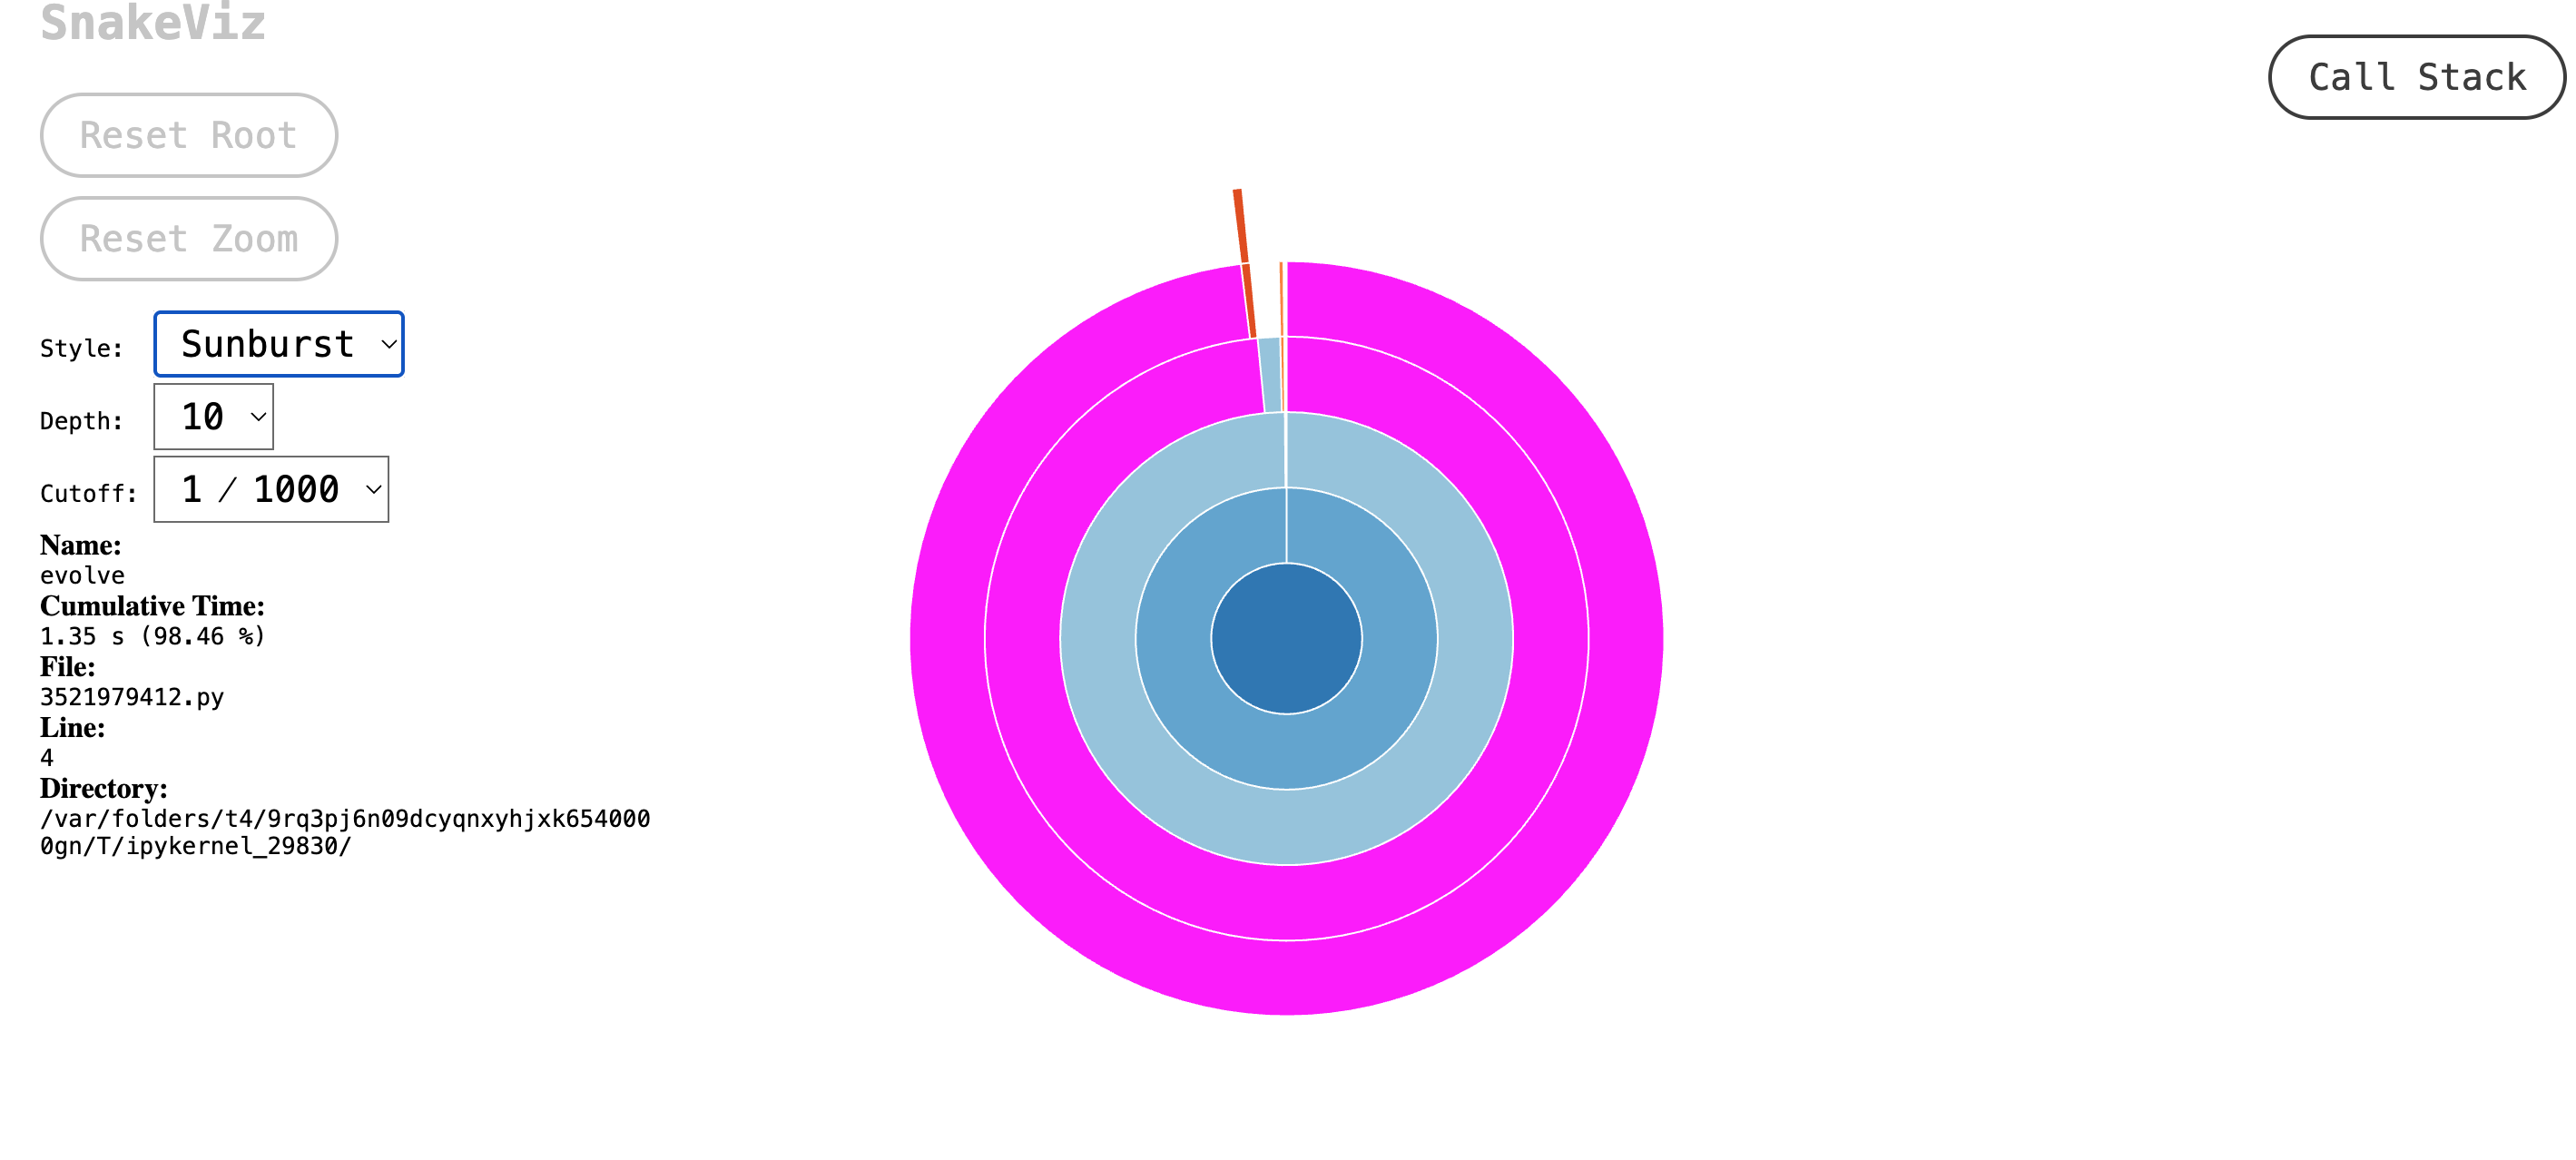

#### Task 2.1 Profile the diffusion code with cProfile and line_profiler the computation

After using cProfile, we see that the majority of time is spent in the evolve function. We use line_profiler to further investigate and add the '@profile' decorator to the function as seen in the screeenshot below.

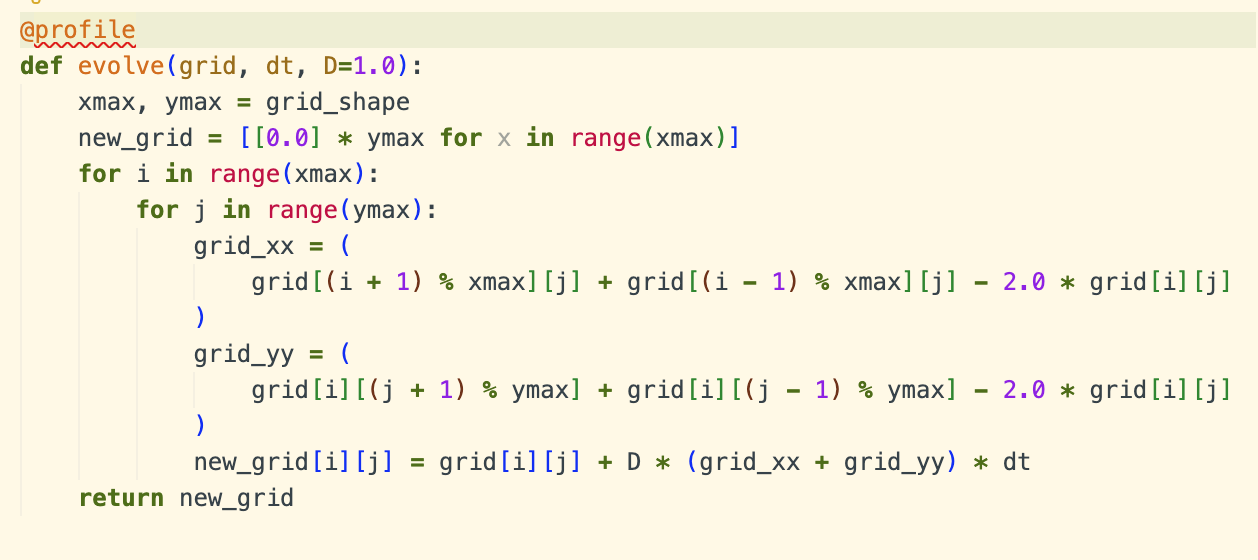

In [6]:
!python -m kernprof -l diffusion.py --num-iterations 10


Wrote profile results to 'diffusion.py.lprof'
Inspect results with:
python -m line_profiler -rmt diffusion.py.lprof


We can then investigate the profilling results below

In [7]:
!python -m line_profiler diffusion.py.lprof

Timer unit: 1e-06 s

Total time: 6.29841 s
File: diffusion.py
Function: evolve at line 6

Line #      Hits         Time  Per Hit   % Time  Line Contents
     6                                           @profile
     7                                           # @profile_cpu(interval=1)
     8                                           def evolve(grid, dt, D=1.0):
     9        10          8.0      0.8      0.0      xmax, ymax = grid_shape
    10        10       3852.0    385.2      0.1      new_grid = [[0.0] * ymax for x in range(xmax)]
    11      6410       1269.0      0.2      0.0      for i in range(xmax):
    12   4102400     700212.0      0.2     11.1          for j in range(ymax):
    13   4096000     598028.0      0.1      9.5              grid_xx = (
    14   4096000    1571154.0      0.4     24.9                  grid[(i + 1) % xmax][j] + grid[(i - 1) % xmax][j] - 2.0 * grid[i][j]
    15                                                       )
    16   4096000     609738.0     

The line_profiler results show that the nested loops (lines 11-12) are the main computational bottleneck, executing 4,096,000 times across the 640×640 grid. The most time-consuming operations are lines 14 and 17, which each account for ~25% of the total program time. Together, these two lines consume about 50% of the function's execution time, followed by line 19 which takes ~20% of time.

The initialization of the new grid (line 10) is negligible, highlighting that the cost is entirely in the nested loops and their memory access patterns rather than setup operations.

### Task 2.2 Memory-profile the diffusion code.

In [20]:
!python -m memory_profiler diffusion.py --num-iterations 5 --grid-shape '(100, 100)'

Filename: diffusion.py

Line #    Mem usage    Increment  Occurrences   Line Contents
     6   64.688 MiB   18.516 MiB           5   @profile
     7                                         # @profile_cpu(interval=1)
     8                                         def evolve(grid, dt, D=1.0):
     9   64.688 MiB  -36.891 MiB           5       xmax, ymax = grid_shape
    10   65.047 MiB -22545.328 MiB        3215       new_grid = [[0.0] * ymax for x in range(xmax)]
    11   68.344 MiB -37102.453 MiB        3205       for i in range(xmax):
    12   68.344 MiB -23764607.047 MiB     2051200           for j in range(ymax):
    13   68.344 MiB -23727495.703 MiB     2048000               grid_xx = (
    14   68.344 MiB -23727532.766 MiB     2048000                   grid[(i + 1) % xmax][j] + grid[(i - 1) % xmax][j] - 2.0 * grid[i][j]
    15                                                     )
    16   68.344 MiB -23727529.750 MiB     2048000               grid_yy = (
    17   68.344 MiB -23727

The memory_profiler results reveal that the primary memory allocation occurs at line 10 when creating the `new_grid` list structure, consuming the majority of the ~5 MiB peak memory usage.
The nested loops (lines 11-19) show the function increasing it's memory level by ~2mb and maintaining this memory level as it performs calculations on the grid data. Finally, line 20's return statement and the function's completion show a significant memory decrease as the old grid is garbage collected, bringing memory usage back down.

Overall, the memory usage is relatively stable after the initial grid creation, suggesting that the function's memory footprint is dominated by the data structure setup rather than accumulating allocations during computation.


In [ ]:
!python -m mprof run diffusion.py --num-iterations 5 --grid-shape '(100, 100)'

mprof.py: Sampling memory every 0.1s
running new process
running as a Python program...


In [15]:
!python -m mprof plot mprofile_20260126113124.dat

Figure(1260x540)


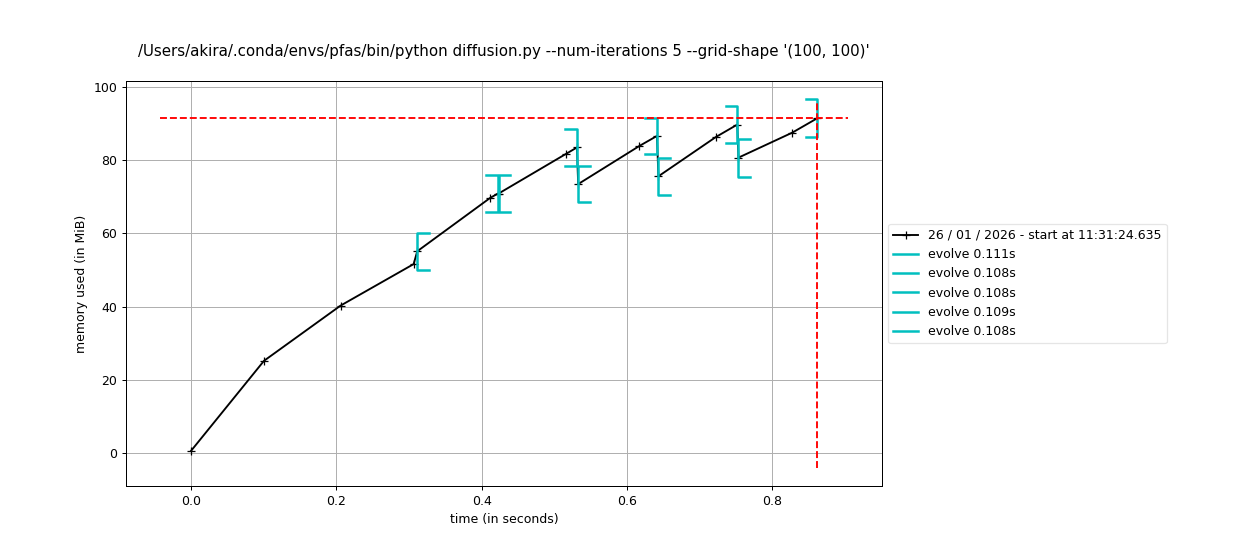

The above plot is the output of running mprof on the evolve function. The graph shows at the later calls of the evolve function a short spike for the allocation of the new grid and deallocation at the return of the function. This is not the case for the first two calls of the evolve function where the memory is still climbing after each call.